# AnalystLab Africa Data Analytics Internship Program
## Week 1: Data Cleaning & Exploratory Data Analysis (EDA)
**Dataset:** Online Retail Transactions
**Prepared by:** DANJUMA ZAINAB
### Objective
The objective of this project is to clean, validate and explore the Online Retail dataset in order to transform raw transactional data into a structured and analysis-ready dataset while identifying meaninful business insights through Exploratory Data Analysis (EDA)

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

In [2]:
df=pd.read_csv(
    "C:/Users/zainab/Desktop/Week 1 Online Retail EDA/Data/OnlineRetail.csv",
    encoding="ISO-8859-1"
)

In [3]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


# 3. Dataset Understanding

In [4]:
df.shape

(541909, 8)

### Interpretation

The Online Retail dataset contains **541,909 rows** and **8 columns**

## Display Columns

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

### Interpretation

The dataset consist of 8 columns these columns are InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country,
    



## Display Column info

This tells us:
- Number of rows
- Number of columns
- Missing values
- Data types


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### Display Datatypes

In [7]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

### Display all numerical columns

In [8]:
numerical_columns=df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['Quantity', 'UnitPrice', 'CustomerID'], dtype='object')


### Display Categorical Columns

In [9]:
categorical_columns=df.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object')


### Check for Possible Primary Keys

#### Check the number of unique values in each column

In [10]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

#### Check if any column is completely unique

In [11]:
for col in df.columns:
    if df[col].is_unique:
        print(f"{col} is unique and could be a primary key.")
    else:
        print(f"{col} is NOT unique.")

InvoiceNo is NOT unique.
StockCode is NOT unique.
Description is NOT unique.
Quantity is NOT unique.
InvoiceDate is NOT unique.
UnitPrice is NOT unique.
CustomerID is NOT unique.
Country is NOT unique.


# Dataset Description
The Online Retail dataset contains transactional records from an online retail store.Each row represents a purchased item and includes information such as Invoice number, Stock Code, Product description, quantity purchased, Invoice date, Unit price', Customer ID, and Country. The dataset is used to analyze customer purchasing behavior. sales performance, and business trends.   


# 4. Data Cleaning

## 4.1 Checking for Missing Values

The dataset was examined for missing values to identify incomplete records that could affect the quality of the analysis. The `isnull().sum()` function was used to count the missing values in each column, while the percentage of missing values was calculated to help determine the most appropriate cleaning method.

In [12]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### Showing missig value in a professional Table

In [14]:

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_table

,Missing Values,Percentage (%)
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


## 4.2 Handling Missing Values

The missing value analysis showed that:

- The **Description** column contained **1,454** missing values (0.27%).
- The **CustomerID** column contained **135,080** missing values (24.93%).

Since the percentage of missing values in the **Description** column was very small, those rows were removed because the product information was unavailable.

The missing values in the **CustomerID** column were retained because they still represent valid sales transactions. These records will only be excluded during customer-level analyses.

### Remove rows with missing descriptions

In [15]:
df=df.dropna(subset=['Description'])

### Verify missing values after cleaning

In [16]:
df.isnull().sum

<bound method DataFrame.sum of         InvoiceNo  StockCode  Description  Quantity  InvoiceDate  UnitPrice  \
0           False      False        False     False        False      False   
1           False      False        False     False        False      False   
2           False      False        False     False        False      False   
3           False      False        False     False        False      False   
4           False      False        False     False        False      False   
...           ...        ...          ...       ...          ...        ...   
541904      False      False        False     False        False      False   
541905      False      False        False     False        False      False   
541906      False      False        False     False        False      False   
541907      False      False        False     False        False      False   
541908      False      False        False     False        False      False   

        CustomerID  

## 4.3 Duplicate Records

The dataset was checked for duplicate records using the `duplicated()` function. A total of **5,268** duplicate rows were identified. These duplicate records were removed using the `drop_duplicates()` function to ensure that each transaction appeared only once in the dataset.

A final verification confirmed that no duplicate records remained after the cleaning process.

### Count Duplicate rows

In [17]:

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


### Remove Duplicate rows

In [18]:
df=df.drop_duplicates()

### Verify that duplicates have been removed

In [19]:

duplicate_count_after = df.duplicated().sum()
print("Number of duplicate rows after cleaning:", duplicate_count_after)

Number of duplicate rows after cleaning: 0


### Duplicate Records Summary

The dataset was checked for duplicate records using the `duplicated()` function. Duplicate rows were identified and removed using the 
    `drop_duplicates()` function. A final check confirmed that no duplicate records remained in the cleaned dataset.

## 4.4 Standardization

To improve data consistency and prepare the dataset for analysis, standardization was performed on the column names, date format, text values, and data types. This ensures the dataset follows a consistent structure and reduces errors during analysis.


### Standardize column names

In [20]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

### Column Name Standardization

The column names were standardized by removing unnecessary spaces, converting all names to lowercase, and replacing spaces with underscores.This 
improves readability and makes the column names easier to reference in Python.

### Check data types


In [21]:
df.dtypes

invoiceno       object
stockcode       object
description     object
quantity         int64
invoicedate     object
unitprice      float64
customerid     float64
country         object
dtype: object

### Convert InvoiceDate to datetime format


In [21]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

### Check the data type again


In [22]:
df['invoicedate'].dtype

dtype('<M8[ns]')

In [23]:
df.dtypes

invoiceno              object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
unitprice             float64
customerid            float64
country                object
dtype: object

### Date Standardization

The **InvoiceDate** column was originally stored as a text (`object`) data type. It was converted to the `datetime` format using the `pd.to_datetime()
`function. This allows accurate time-based analysis such as monthly sales trends and yearly comparisons.

In [22]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])
df['invoicedate'].dtype

dtype('<M8[ns]')

## 4.5 Data Validation

Data validation was performed to identify invalid values, inconsistent records, incorrect formats, and anomalies that could affect the accuracy of the analysis.

The validation focused on:

- Negative quantities
- Zero or negative unit prices
- Cancelled transactions

These checks help ensure that only meaningful and reliable records are used for analysis.

### Negative Quantities

A total of **9,725** records contained negative quantities. These records represent returned products or cancelled customer orders rather than completed sales. They were identified as valid business events instead of data entry errors.

In [23]:
negative_quantity = df[df['quantity'] < 0]
negative_quantity.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


#### Count Negative Quantities

In [24]:
negative_quantity.shape[0]

9725

### Zero or Negative Unit Prices

A total of **1,058** records had a unit price of zero or less. These transactions may represent promotional items, internal adjustments, free products, or data entry anomalies. These records were identified for further review before analysis.

In [25]:
invalid_price = df[df['unitprice'] <= 0]
invalid_price.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
6391,536941,22734,amazon,20,2010-12-03 12:08:00,0.0,NaN,United Kingdom
6392,536942,22139,amazon,15,2010-12-03 12:08:00,0.0,NaN,United Kingdom
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.0,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
13217,537425,84968F,check,-20,2010-12-06 15:35:00,0.0,NaN,United Kingdom


#### Count invalid prices

In [26]:
invalid_price.shape[0]

1058

### Cancelled Transactions

Invoice numbers beginning with the letter **"C"** represent cancelled transactions. A total of **9,251** cancelled transactions were identified. These records correspond to returned or cancelled customer orders and should be excluded when analysing completed sales performance.

In [27]:
cancelled_orders = df[df['invoiceno'].astype(str).str.startswith('C')]
cancelled_orders.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


#### Count Cancelled Transactions

In [28]:
cancelled_orders.shape[0]

9251

### Handling Invalid Records

Cancelled transactions, negative quantities, and records with zero or negative unit prices were excluded from the cleaned dataset because they do 
not represent completed sales transactions and could bias the analysis.

In [29]:
# Remove cancelled transactions
df = df[~df['invoiceno'].astype(str).str.startswith('C')]

# Remove negative quantities
df = df[df['quantity'] > 0]

# Remove zero or negative unit prices
df = df[df['unitprice'] > 0]

## 4.6 Cleaning Summary

In [30]:
cleaning_summary = pd.DataFrame({
    "Issue Found": [
        "Missing Values",
        "Duplicate Records",
        "Column Standardization",
        "Date Standardization",
        "Negative Quantities",
        "Zero/Negative Unit Prices",
        "Cancelled Transactions"
    ],
    "Action Taken": [
        "Removed rows with missing Description and retained missing CustomerID.",
        "Removed 5,268 duplicate rows.",
        "Converted column names to lowercase.",
        "Converted InvoiceDate to datetime format.",
        "Identified 9,725 records and removed them.",
        "Identified 1,058 records and removed them.",
        "Identified 9,251 cancelled transactions and removed them."
    ]
})

cleaning_summary

,Issue Found,Action Taken
0,Missing Values,Removed rows with missing Description and reta...
1,Duplicate Records,"Removed 5,268 duplicate rows."
2,Column Standardization,Converted column names to lowercase.
3,Date Standardization,Converted InvoiceDate to datetime format.
4,Negative Quantities,"Identified 9,725 records and removed them."
5,Zero/Negative Unit Prices,"Identified 1,058 records and removed them."
6,Cancelled Transactions,"Identified 9,251 cancelled transactions and re..."


### Save the cleaned dataset

In [31]:
df.to_csv("OnlineRetail_Cleaned.csv", index=False)


In [33]:
print("Cleaned datset saved successfully!")

Cleaned datset saved successfully!


# 5. Exploratory Data Analysis (EDA)

## 5.1 Summary Statistics

Summary statistics were generated to understand the distribution and characteristics of the numerical variables in the cleaned dataset. The statistics 
include the mean, median, minimum, maximum, and standard deviation.

### Summary statistics for numerical columns


In [34]:
df.describe()

,quantity,invoicedate,unitprice,customerid
count,524878.000000,524878,524878.000000,392692.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,156.280031,NaN,36.093028,1713.539549


## Interpretation

The summary statistics provide an overview of the key numerical variables in the Online Retail Transactions dataset.

- The cleaned dataset contains **524,878** completed sales transactions.
- The average quantity purchased per transaction is approximately **10.62** items, while the median quantity is **4** items. This indicates that most 
customers purchase relatively small quantities, although a few transactions involve very large orders.
- Product unit prices range from **0.001** to **13,541.33**, with an average unit price of **3.92**. The large difference between the average and
maximum values suggests the presence of high-priced products or exceptional transactions.
- Customer IDs range from **12,346** to **18,287**, representing a large customer base.
- The transaction dates span from **1 December 2010** to **9 December 2011**, providing approximately one year of retail sales data.
- The high standard deviation for both **Quantity (156.28)** and **Unit Price (36.09)** indicates considerable variation in customer purchasing
behaviour and product pricing across transactions.

## 5.2 Revenue Calculation

A new variable named **Revenue** was created by multiplying the quantity purchased by the unit price. This variable will be used to evaluate product performance, customer spending, and country-level sales.

### Create Revenue Column


In [35]:
df['revenue'] = df['quantity'] * df['unitprice']
df.head(10)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08


## Interpretation

A new variable called **Revenue** was created by multiplying the **Quantity** sold by the **Unit Price** for each transaction.

This variable provides a direct measure of the sales value generated from each transaction and serves as the basis for analysing product performance, country-level revenue, monthly sales trends, and customer purchasing behaviour.

## 5.3 Top 10 Selling Products

This analysis identifies the products with the highest total quantity sold after the data cleaning process.

In [36]:
top_products = (
    df.groupby('description')['quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: quantity, dtype: int64

## Interpretation
The analysis shows that **PAPER CRAFT, LITTLE BIRDIE** was the best-selling product with **80,995 units sold**, followed by **MEDIUM CERAMIC TOP STORAGE JAR** with **78,033 units**.
Several decorative and household products such as **JUMBO BAG RED RETROSPOT**, **WHITE HANGING HEART T-LIGHT HOLDER**, and **PACK OF 72 RETROSPOT CAKE CASES** also recorded high sales volumes. This suggests that home décor and gift items were among the most popular products purchased by customers.

## 5.4 Highest Revenue-Generating Countries
This analysis examines the countries that generated the highest total revenue from completed sales transactions.

In [37]:

top_countries = (
    df.groupby('country')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_countries


country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: revenue, dtype: float64

## Interpretation

The **United Kingdom** generated the highest total revenue, contributing approximately **£9.00 million**, making it the company's largest market by a significant margin.

Other major revenue-generating countries include the **Netherlands**, **EIRE (Ireland)**, **Germany**, and **France**. These findings indicate that although the business serves multiple countries, sales revenue is heavily concentrated in the United Kingdom.

## 5.5 Monthly Sales Trend

This analysis evaluates how sales revenue changed over time by aggregating total monthly revenue.

### Create month column

In [38]:

df['month'] = df['invoicedate'].dt.to_period('M').astype(str)

monthly_sales = (
    df.groupby('month')['revenue']
      .sum()
      .sort_values()
)

monthly_sales

month
2011-02     522545.560
2011-04     536968.491
2011-12     637790.330
2011-01     689811.610
2011-03     716215.260
2011-07     718076.121
2011-08     757841.380
2011-06     760547.010
2011-05     769296.610
2010-12     821452.730
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
Name: revenue, dtype: float64

## Interpretation

Monthly revenue analysis reveals fluctuations in sales performance throughout the study period.

Revenue steadily increased during the second half of 2011, with **November 2011** recording the highest monthly revenue of approximately **£1.50 million**. Conversely, **February 2011** recorded the lowest monthly revenue of approximately **£522,546**.

The increase in sales during the final quarter of the year suggests seasonal demand, likely influenced by holiday shopping and year-end promotions.

## 5.6 Most Frequently Purchased Products

This analysis identifies the products that appeared most frequently across customer transactions.

In [39]:
most_purchased = (
    df.groupby('description')['invoiceno']
      .count()
      .sort_values(ascending=False)
      .head(10)
)

most_purchased

description
WHITE HANGING HEART T-LIGHT HOLDER    2311
JUMBO BAG RED RETROSPOT               2109
REGENCY CAKESTAND 3 TIER              2007
PARTY BUNTING                         1699
LUNCH BAG RED RETROSPOT               1581
ASSORTED COLOUR BIRD ORNAMENT         1476
SET OF 3 CAKE TINS PANTRY DESIGN      1392
PACK OF 72 RETROSPOT CAKE CASES       1352
LUNCH BAG  BLACK SKULL.               1301
NATURAL SLATE HEART CHALKBOARD        1255
Name: invoiceno, dtype: int64

## Interpretation

The **WHITE HANGING HEART T-LIGHT HOLDER** appeared in the highest number of transactions (**2,311** purchases), making it the most frequently purchased product.

Other frequently purchased products include **JUMBO BAG RED RETROSPOT**, **REGENCY CAKESTAND 3 TIER**, and **PARTY BUNTING**, indicating consistent customer demand for decorative household and gift-related products.

## 5.7 Customer Purchasing Behaviour

This analysis identifies customers with the highest total spending based on completed transactions.

In [40]:
customer_spending = (
    df.groupby('customerid')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

customer_spending

customerid
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: revenue, dtype: float64

## Interpretation

Customer purchasing behaviour analysis shows that **Customer ID 14646** generated the highest total revenue of approximately **£280,206**, followed by **Customer ID 18102** with **£259,657**.

The results indicate that a relatively small number of customers contribute significantly to total sales revenue, highlighting the importance of retaining high-value customers through targeted marketing and customer relationship management strategies.

## 5.8 Key EDA Findings

The exploratory data analysis revealed several important patterns within the Online Retail Transactions dataset:

1. **PAPER CRAFT, LITTLE BIRDIE** was the highest-selling product with **80,995 units sold**, indicating exceptionally strong customer demand.

2. The **United Kingdom** generated approximately **£9.00 million** in revenue, making it the company's largest market by a considerable margin.

3. Sales revenue peaked in **November 2011**, suggesting increased customer spending during the holiday shopping season.

4. **WHITE HANGING HEART T-LIGHT HOLDER** was the most frequently purchased product, appearing in **2,311** customer transactions.

5. Customer **14646** generated the highest total revenue, demonstrating that a small group of customers contributes substantially to overall sales.

# 6. Key Insights

### Insight 1
The United Kingdom is the company's dominant market, generating over **£9 million** in revenue. This indicates that the business relies heavily on domestic sales.

### Insight 2
Home décor and gift products dominate customer purchases, as reflected by the high sales volumes of products such as **PAPER CRAFT, LITTLE BIRDIE** and **WHITE HANGING HEART T-LIGHT HOLDER**.

### Insight 3
Sales reached their highest level in **November 2011**, suggesting strong seasonal demand during the holiday period.

### Insight 4
A relatively small number of customers contribute a significant proportion of total revenue, highlighting opportunities for customer retention and loyalty programmes.

### Insight 5
Creating a revenue metric enabled deeper business analysis beyond sales quantity, allowing the identification of top-performing countries, customers, and sales periods.

# 7. Data Visualization

This section prevents visual representations of the exploratory data analysis performed on the cleaned Oline Retail Transactions dataset. This charts help identify trends, patterns, and relationahips within the data. 

## 7.1 Top 10 Selling Products

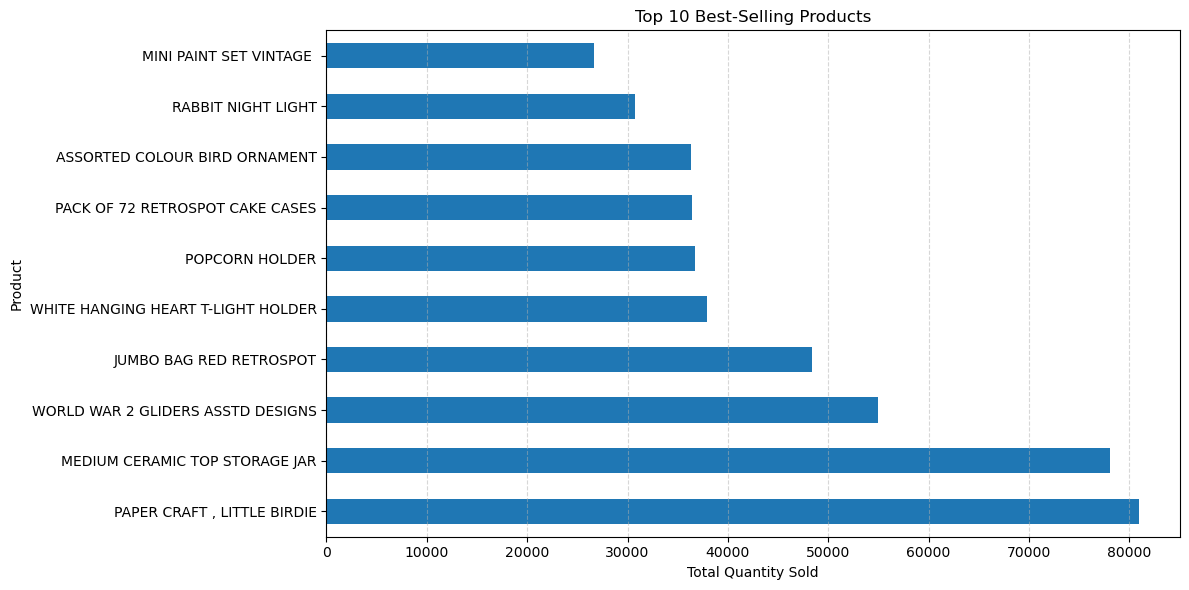

In [41]:
plt.figure(figsize=(12,6))

top_products.plot(kind='barh')

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpetation

**Finding:**

The chart shows that **PAPER CRAFT, LITTLE BIRDIE** recorded the highest quantity sold, followed by **MEDIUM CERAMIC TOP STORAGE JAR**. Decorative and household products dominate the list of best-selling items. 

## 7.2 Highest Revenue-Generating Countries 

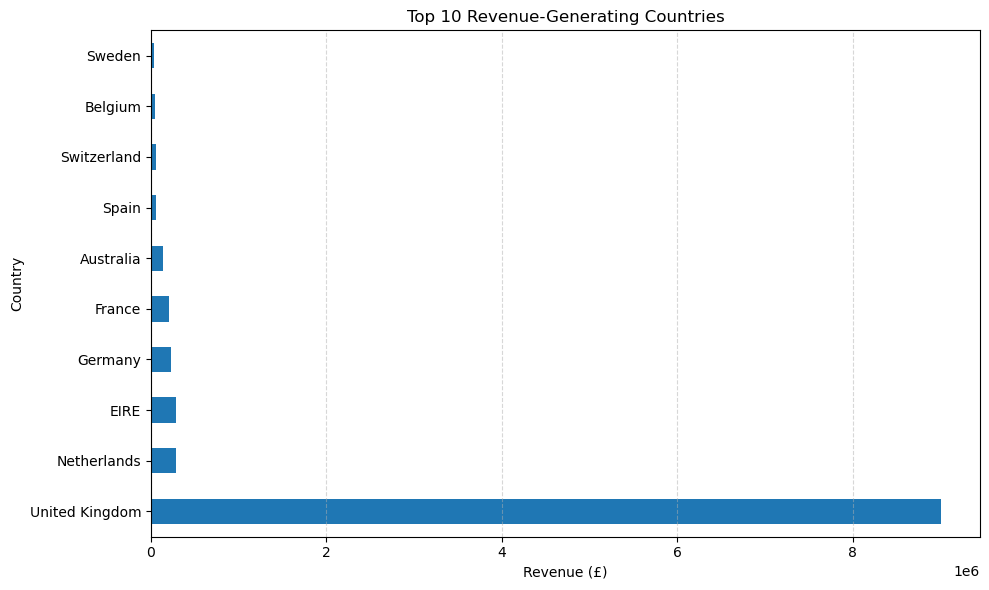

In [42]:
plt.figure(figsize=(10,6))

top_countries.plot(kind='barh')

plt.title("Top 10 Revenue-Generating Countries")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Interpretation

**Findings:**

The United Kingdom generated the highest revenue by a significant margin, making it the company's primary revenue source.

## 7.3 Monthly Sales Trend

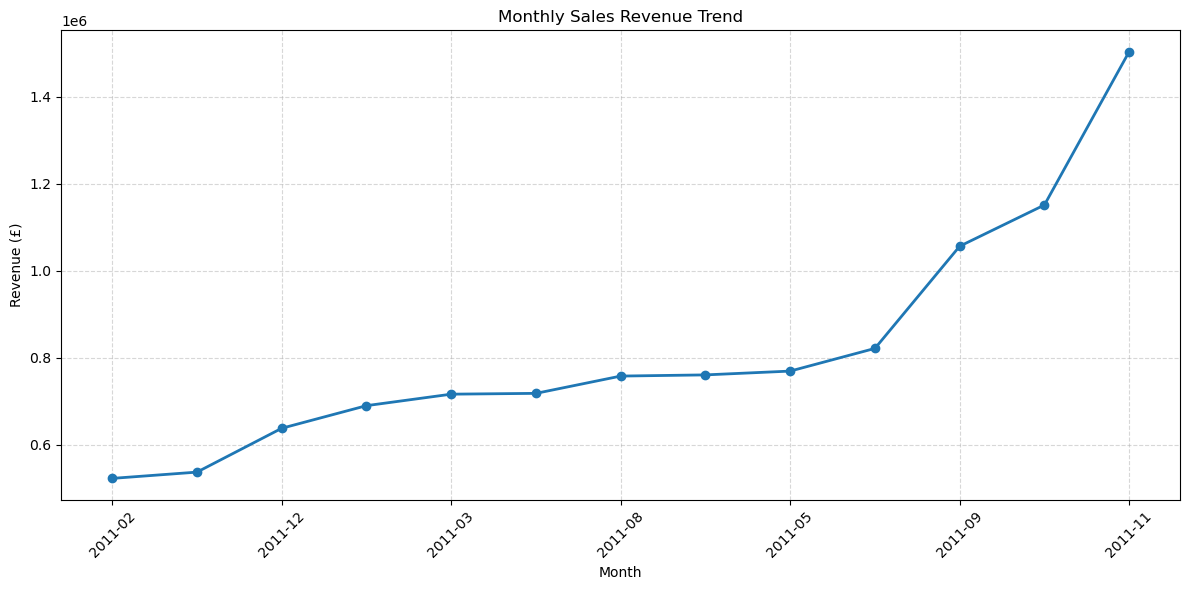

In [43]:
plt.figure(figsize=(12,6))

monthly_sales.plot(
    kind='line',
    marker='o',
    linewidth=2
)

plt.title("Monthly Sales Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Interpretation

**Findings:**

Sales revenue generally increased throughout the year and reached its highest point i **November 2011**, indicating strong seasonal demand
  

## 7.4 Most Frequently Purchased Products

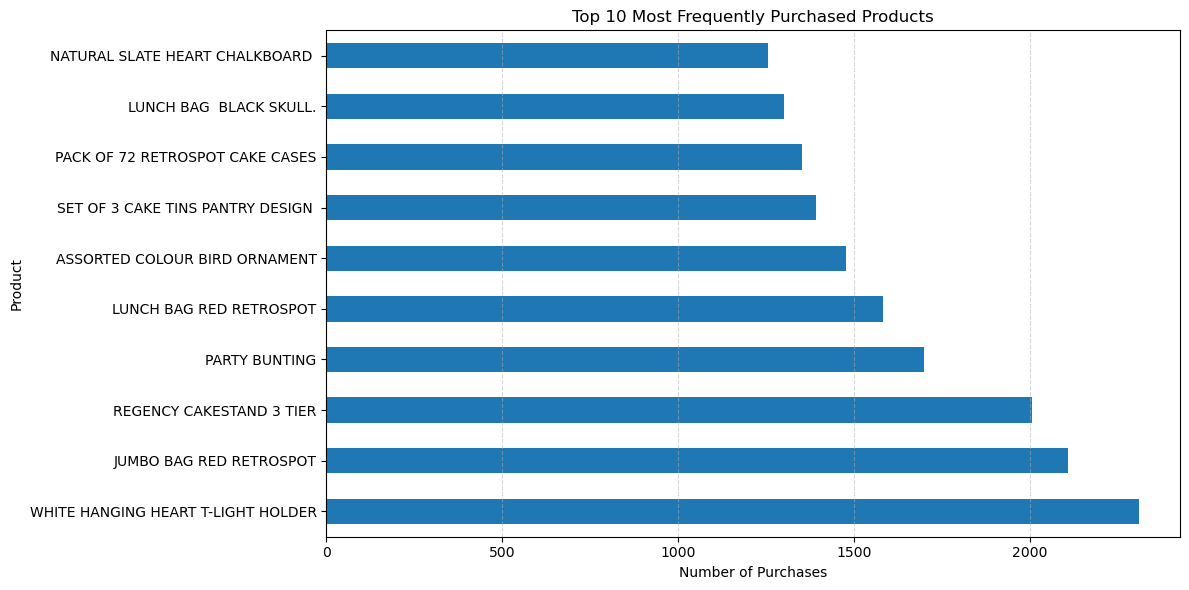

In [44]:
plt.figure(figsize=(12,6))

most_purchased.plot(kind='barh')

plt.title("Top 10 Most Frequently Purchased Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Interpretation

**Findings:**

The **WHITE HANGING HEART T-LIGHT HOLDER** appeared most frequently across customer transactions, showing consistent customer demand.

## 7.5 Top Customers by Revenue

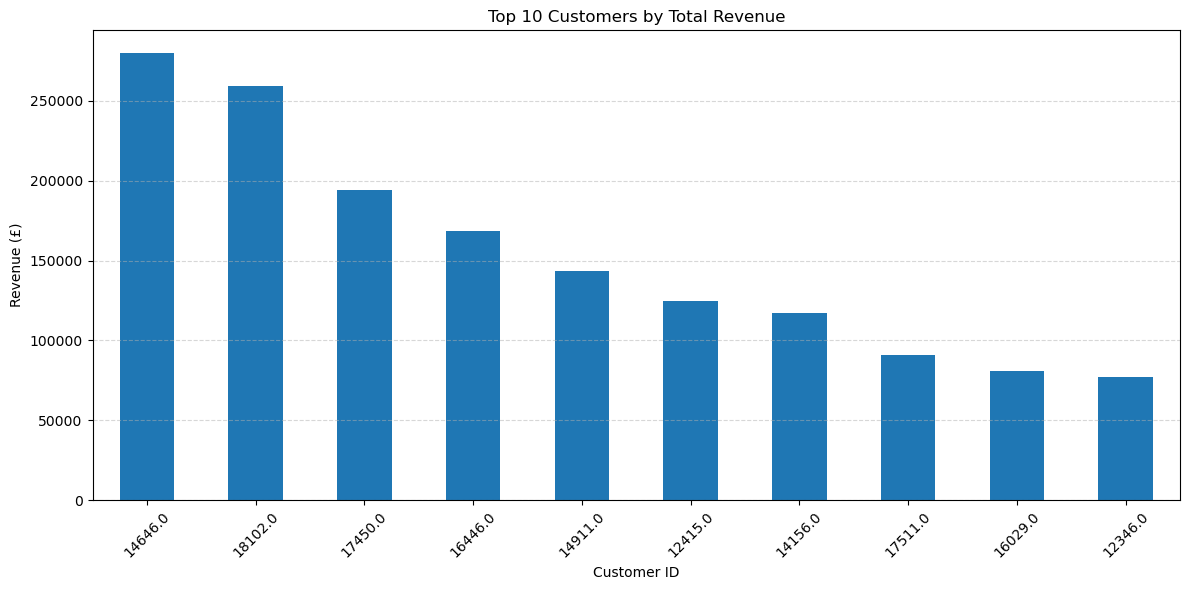

In [45]:
plt.figure(figsize=(12,6))

customer_spending.plot(kind='bar')

plt.title("Top 10 Customers by Total Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Interpretation

**Findings:**

Customer **14646** generated the highest total revenue, followed by customers **18102** and **17450**, indicating that a small number of customers contributed significantly to overall sales.